In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import os
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import torchvision.models as models
from tqdm import tqdm

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset path
dataset_path = "C:/Users/91995/Downloads/PlantVillage-Dataset-master/PlantVillage-Dataset-master/raw/color"
img_size = 128
batch_size = 16
num_classes = 38  # Explicitly setting the number of classes

# Image transformations
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize between -1 and 1
])

classes = os.listdir(dataset_path)
print(f"Total classes: {len(classes)}")

Total classes: 38


In [11]:
# Load dataset
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Splitting dataset: 60% Train, 20% Validation, 20% Test
train_size = int(0.6 * len(full_dataset))
val_size = int(0.2 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Data loaders
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [12]:
# Extract class names
class_names = full_dataset.classes  # List of actual class names
num_classes = len(class_names)  
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [13]:
class SegNetClassifier(nn.Module):
    def __init__(self, num_classes=38):
        super(SegNetClassifier, self).__init__()

        self.encoder = models.vgg16(pretrained=True).features  # Using VGG16 as backbone
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # This ensures a fixed-size output
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.encoder(x)
        x = self.global_avg_pool(x)  # Ensures the correct shape
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [14]:
model = SegNetClassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
scaler = torch.cuda.amp.GradScaler()
optimizer = optim.Adam(model.parameters(), lr=0.001)

C:\Users\91995\AppData\Local\Temp\ipykernel_36500\4093298455.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\91995\anaconda3\Lib\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


In [15]:
def train(model, train_loader, val_loader, epochs=10):
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        
        # Training phase
        with tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}") as t:
            for images, labels in t:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

                t.set_postfix(loss=loss.item())

        train_accuracy = correct / total
        train_acc.append(train_accuracy)
        print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_accuracy:.4f}")
        
        # Validation phase
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        val_accuracy = correct / total
        val_acc.append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs}, Validation Acc: {val_accuracy:.4f}")

        # Step the learning rate scheduler
        scheduler.step()
    
    return train_acc, val_acc

In [16]:
train_acc, val_acc = train(model, train_loader, val_loader, epochs=5)

C:\Users\91995\AppData\Local\Temp\ipykernel_36500\3994214694.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/5: 100%|██████████████████████████████████████████████████████| 2037/2037 [2:40:31<00:00,  4.73s/it, loss=1.47]


Epoch 1/5, Train Acc: 0.4834


C:\Users\91995\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/5, Validation Acc: 0.7221


Epoch 2/5: 100%|█████████████████████████████████████████████████████| 2037/2037 [9:57:10<00:00, 17.59s/it, loss=0.881]


...

Epoch 3/5, Train Acc: 0.8635
Epoch 3/5, Validation Acc: 0.8883


Epoch 4/5: 100%|████████████████████████████████████████████████████| 2037/2037 [1:40:51<00:00,  2.97s/it, loss=0.0337]


Epoch 4/5, Train Acc: 0.8889
Epoch 4/5, Validation Acc: 0.8818


Epoch 5/5: 100%|████████████████████████████████████████████████████| 2037/2037 [1:47:57<00:00,  3.18s/it, loss=0.0701]


Epoch 5/5, Train Acc: 0.9082
Epoch 5/5, Validation Acc: 0.9168


In [17]:
model_name = model.__class__.__name__  # Get the class name dynamically
model_path = f"{model_name.lower()}_trained.pth"  # Generate filename dynamically
torch.save(model.state_dict(), model_path)
print(f"\n🚀 Model saved as {model_path}")


🚀 Model saved as segnetclassifier_trained.pth


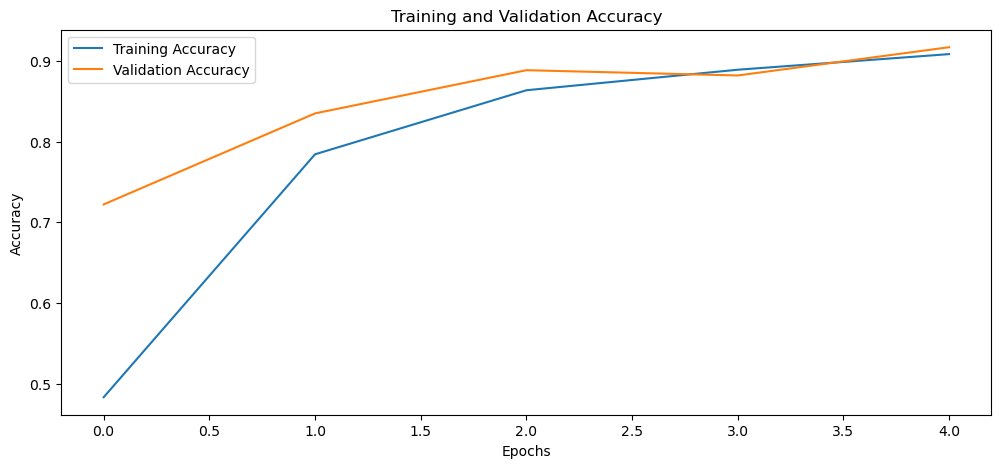

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [19]:
def test(model, test_loader):
    model.eval()
    y_true, y_scores = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    return np.array(y_true), np.array(y_scores)

y_true, y_scores = test(model, test_loader)

Test Accuracy: 0.9128


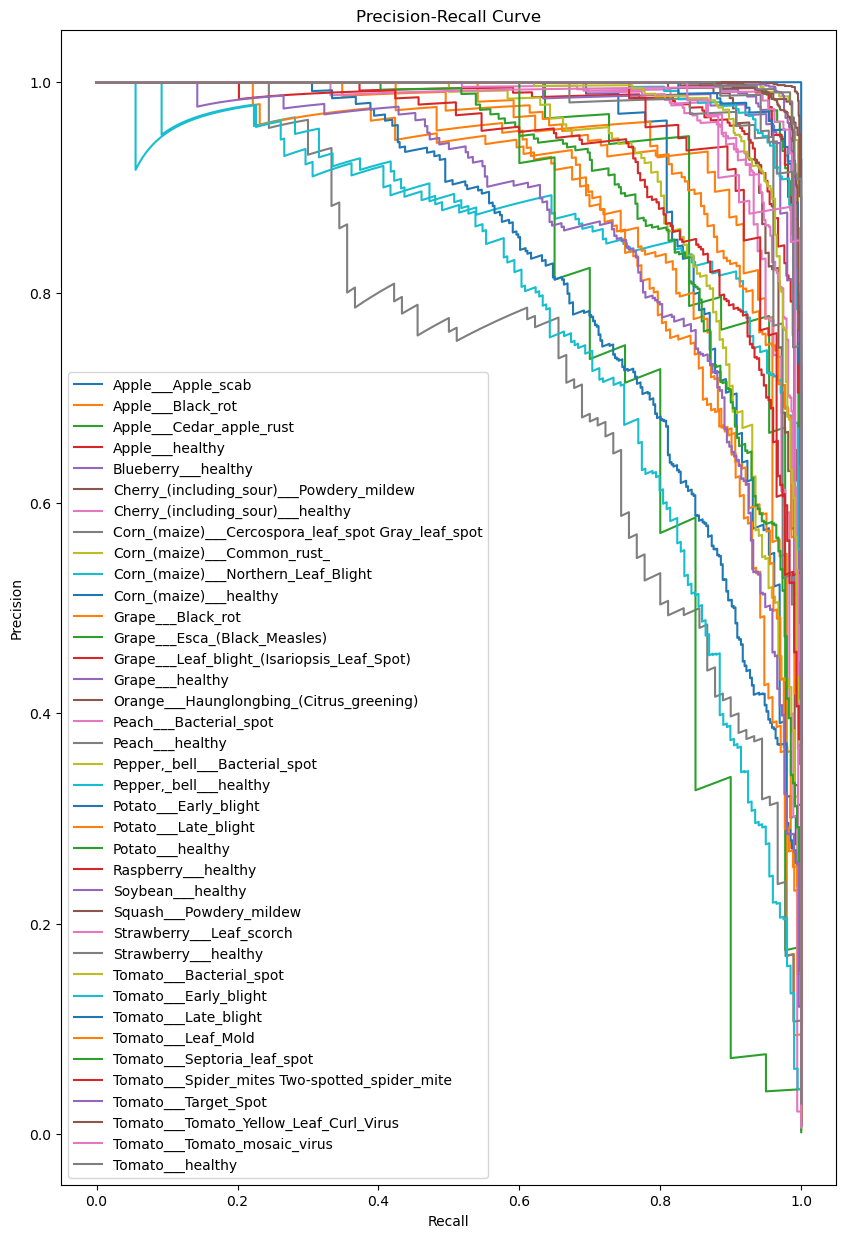

In [20]:
precision = dict()
recall = dict()
plt.figure(figsize=(10, 15))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true == i, y_scores[:, i])
    plt.plot(recall[i], precision[i], label=f'{class_names[i]}')  # Use class name

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()